# Krusell-Smith (1998) モデルのシミュレーション

## モデルの概要

**Krusell and Smith (1998, JPE)** は不完全市場（incomplete markets）と**総体的不確実性（aggregate uncertainty）**を組み合わせた異質エージェントモデルです。

### 主な特徴

1. **異質エージェント**: 各個人は固有の労働所得ショックを受ける（ex-post 異質性）
2. **不完全市場**: 借入制約があり、保険市場が不完全
3. **総体的ショック**: TFP（全要素生産性）が確率的に変動
4. **有界合理性**: エージェントは「線形予測ルール」で総体資本を予測する

### エージェントの問題

$$\max_{\{c_t, a_{t+1}\}} \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t u(c_t)$$

$$\text{s.t.} \quad c_t + a_{t+1} = (1 + r_t) a_t + w_t \ell_t$$

$$a_{t+1} \geq \underline{a}, \quad c_t \geq 0$$

ここで $\ell_t \in \{0, 1\}$ は雇用状態（0=失業, 1=就業）。

### 企業の問題

代表的企業は次の生産関数を持つ：

$$Y_t = z_t K_t^\alpha L_t^{1-\alpha}$$

競争均衡では：
$$r_t = \alpha z_t (K_t/L_t)^{\alpha-1} - \delta$$
$$w_t = (1-\alpha) z_t (K_t/L_t)^\alpha$$

### Krusell-Smith の近似解法

状態空間が無限次元（資産分布 $\Phi_t$ が状態変数）なので、エージェントは平均資本 $\bar{K}_t$ のみを用いた**線形予測ルール**を使う：

$$\log \bar{K}_{t+1} = a_z + b_z \log \bar{K}_t \quad (z \in \{g, b\})$$

この係数 $(a_z, b_z)$ を自己整合的に（ALM = PLM となるよう）更新する。

## 1. パッケージの読み込みとパラメータ設定

In [1]:
using LinearAlgebra
using Statistics
using Random
using Plots
using Printf

# 再現性のためのシード
Random.seed!(42)

println("パッケージ読み込み完了")

パッケージ読み込み完了


In [2]:
# ===== パラメータ =====
struct KSParams
    # 選好
    β::Float64       # 割引因子
    γ::Float64       # 相対的危険回避度

    # 生産
    α::Float64       # 資本分配率
    δ::Float64       # 減価償却率

    # 集計ショック（TFP）
    z_g::Float64     # 好況時の TFP
    z_b::Float64     # 不況時の TFP

    # 雇用状態
    u_g::Float64     # 好況時の失業率
    u_b::Float64     # 不況時の失業率

    # 借入制約
    a_min::Float64
    a_max::Float64
    n_a::Int         # 資産グリッド数

    # 集計資本グリッド（近似用）
    K_min::Float64
    K_max::Float64
    n_K::Int

    # シミュレーション
    T::Int           # 時系列長
    N::Int           # エージェント数
    T_discard::Int   # バーンイン期間

    # 収束基準
    tol_vfi::Float64
    tol_km::Float64
    max_iter::Int
end

p = KSParams(
    0.99,    # β
    1.0,     # γ（対数効用）
    0.36,    # α
    0.025,   # δ
    1.01,    # z_g
    0.99,    # z_b
    0.04,    # u_g
    0.10,    # u_b
    0.0,     # a_min
    200.0,   # a_max
    100,     # n_a
    30.0,    # K_min
    50.0,    # K_max
    4,       # n_K
    2000,    # T
    5000,    # N
    500,     # T_discard
    1e-8,    # tol_vfi
    1e-5,    # tol_km
    1000,    # max_iter
)

println("パラメータ設定完了")
println("β = ", p.β, ", α = ", p.α, ", δ = ", p.δ)

パラメータ設定完了
β = 0.99, α = 0.36, δ = 0.025


## 2. マルコフ連鎖の設定

### 状態空間
- **集計状態** $z \in \{z_g, z_b\}$（好況・不況）
- **個人状態** $\ell \in \{0, 1\}$（失業・就業）

Krusell-Smith (1998) のオリジナルに従い、4×4 の遷移行列を構築する。

In [3]:
# ===== マルコフ連鎖の構築 =====
# 状態インデックス: (z, ℓ) = (好況就業=1, 好況失業=2, 不況就業=3, 不況失業=4)

function build_transition_matrix(p::KSParams)
    u_g, u_b = p.u_g, p.u_b

    # 集計状態の平均滞在期間（Krusell-Smith 1998 の設定）
    d_gg = 8.0   # 好況の平均継続期間（四半期）
    d_bb = 8.0   # 不況の平均継続期間

    p_gg = 1.0 - 1.0/d_gg   # 好況→好況
    p_bb = 1.0 - 1.0/d_bb   # 不況→不況
    p_gb = 1.0 - p_gg        # 好況→不況
    p_bg = 1.0 - p_bb        # 不況→好況

    # 個人失業の遷移確率（集計状態から決まる）
    # 雇用状態の遷移行列（就業維持率）
    # Krusell-Smith 1998 の式より逆算
    # p(ℓ'=1|ℓ=1,z→z') を整合的に設定

    # 好況→好況 のとき: 就業維持率
    p_ee_gg = p_gg - p_gb * (u_g - u_b) / (1.0 - u_g) / p_gg * p_gg
    # 簡略化のため直接設定（Krusell-Smith 補完パラメータ）
    p_uu_bb = 1.0 - (1.0 - u_b) * (1.0 - p_bb) / u_b

    # 4状態: (g,e), (g,u), (b,e), (b,u)
    # 就業率: 1-u_g (好況), 1-u_b (不況)
    # 各集計状態遷移のもとで、失業率変化と整合的な個人遷移を設定

    # 集計遷移確率
    π_agg = [p_gg p_gb; p_bg p_bb]

    # 個人状態の遷移行列（4×4）
    # 行: 今期の(z,ℓ), 列: 来期の(z,ℓ)
    # 失業率の整合性条件から導出
    Π = zeros(4, 4)

    # 好況→好況 のブロック (行1,2 → 列1,2)
    # 集計失業率 u_g を維持
    p_eu_gg = p_gg * u_g / (1.0 - u_g)  # 近似
    p_eu_gg = min(max(p_eu_gg, 0.0), 1.0)
    p_ee_gg = p_gg - p_eu_gg

    Π[1,1] = p_ee_gg      # (g,e)→(g,e)
    Π[1,2] = p_eu_gg      # (g,e)→(g,u)
    Π[2,1] = p_gg * u_g   # (g,u)→(g,e) ※就業転換
    Π[2,2] = p_gg - Π[2,1] # (g,u)→(g,u)

    # 好況→不況 のブロック (行1,2 → 列3,4)
    p_eu_gb = p_gb * u_b / (1.0 - u_g)  # 近似
    p_eu_gb = min(max(p_eu_gb, 0.0), 1.0)
    Π[1,3] = p_gb - p_eu_gb
    Π[1,4] = p_eu_gb
    Π[2,3] = p_gb * (1.0 - u_b)
    Π[2,4] = p_gb - Π[2,3]

    # 不況→不況 のブロック (行3,4 → 列3,4)
    p_eu_bb = p_bb * u_b / (1.0 - u_b)  # 近似
    p_eu_bb = min(max(p_eu_bb, 0.0), 1.0)
    Π[3,3] = p_bb - p_eu_bb
    Π[3,4] = p_eu_bb
    Π[4,3] = p_bb * (1.0 - u_b)
    Π[4,4] = p_bb - Π[4,3]

    # 不況→好況 のブロック (行3,4 → 列1,2)
    p_eu_bg = p_bg * u_g / (1.0 - u_b)  # 近似
    p_eu_bg = min(max(p_eu_bg, 0.0), 1.0)
    Π[3,1] = p_bg - p_eu_bg
    Π[3,2] = p_eu_bg
    Π[4,1] = p_bg * (1.0 - u_g)
    Π[4,2] = p_bg - Π[4,1]

    # 行を正規化（数値誤差対策）
    for i in 1:4
        Π[i,:] = max.(Π[i,:], 0.0)
        Π[i,:] ./= sum(Π[i,:])
    end

    return Π, π_agg
end

Π, π_agg = build_transition_matrix(p)

println("4状態遷移行列 Π（行=今期, 列=来期）:")
println("  状態: (g,就業) (g,失業) (b,就業) (b,失業)")
for i in 1:4
    @printf "  行%d: %.4f  %.4f  %.4f  %.4f\n" i Π[i,1] Π[i,2] Π[i,3] Π[i,4]
end
println()
println("行和の確認（≈1）: ", [sum(Π[i,:]) for i in 1:4])

4状態遷移行列 Π（行=今期, 列=来期）:
  状態: (g,就業) (g,失業) (b,就業) (b,失業)
  行1: 0.8385  0.0365  0.1120  0.0130
  行2: 0.0350  0.8400  0.1125  0.0125
  行3: 0.1194  0.0056  0.7778  0.0972
  行4: 0.1200  0.0050  0.7875  0.0875

行和の確認（≈1）: [1.0, 1.0, 1.0, 1.0]


## 3. グリッドの設定

In [4]:
# ===== グリッドの設定 =====

# 資産グリッド（低資産側を細かく：等比間隔）
function make_asset_grid(a_min, a_max, n_a; curve=3.0)
    # curve > 1 で低資産側が細かくなる
    grid = range(0.0, 1.0, length=n_a) .^ curve
    return a_min .+ (a_max - a_min) .* grid
end

a_grid = make_asset_grid(p.a_min, p.a_max, p.n_a)

# 集計資本グリッド
K_grid = range(p.K_min, p.K_max, length=p.n_K) |> collect

# 集計状態: 1=好況(g), 2=不況(b)
z_vals = [p.z_g, p.z_b]

# 個人状態: 1=就業(e), 2=失業(u)
ℓ_vals = [1.0, 0.0]

println("資産グリッド（最初の10点）:")
println(round.(a_grid[1:10], digits=3))
println("資産グリッド（最後の5点）:")
println(round.(a_grid[end-4:end], digits=2))
println()
println("集計資本グリッド: ", K_grid)
println("TFP 状態: ", z_vals)

資産グリッド（最初の10点）:
[0.0, 0.0, 0.002, 0.006, 0.013, 0.026, 0.045, 0.071, 0.106, 0.15]
資産グリッド（最後の5点）:
[176.72, 182.36, 188.12, 194.0, 200.0]

集計資本グリッド: [30.0, 36.666666666666664, 43.333333333333336, 50.0]
TFP 状態: [1.01, 0.99]


## 4. 均衡価格の計算

競争均衡では、資本と労働の限界生産物が要素価格に等しい：

$$r(z, K) = \alpha z \left(\frac{K}{L(z)}\right)^{\alpha-1} - \delta$$

$$w(z, K) = (1-\alpha) z \left(\frac{K}{L(z)}\right)^{\alpha}$$

ここで $L(z) = 1 - u_z$（集計労働供給）。

In [5]:
# ===== 均衡価格の関数 =====

function get_prices(z, K, p::KSParams)
    # 集計労働供給（就業率）
    L = (z == p.z_g) ? (1.0 - p.u_g) : (1.0 - p.u_b)
    KL = K / L
    r = p.α * z * KL^(p.α - 1.0) - p.δ
    w = (1.0 - p.α) * z * KL^p.α
    return r, w
end

# 確認
K_ss = 40.0  # ステディステート付近
r_g, w_g = get_prices(p.z_g, K_ss, p)
r_b, w_b = get_prices(p.z_b, K_ss, p)

@printf "好況: r=%.4f, w=%.4f\n" r_g w_g
@printf "不況: r=%.4f, w=%.4f\n" r_b w_b

好況: r=0.0084, w=2.4753
不況: r=0.0064, w=2.4833


## 5. 価値関数反復（Value Function Iteration）

エージェントの動的計画問題を VFI で解く。

**状態**: $(a, \ell, z, K)$（個人資産、雇用状態、TFP、集計資本）

ベルマン方程式：

$$V(a, \ell; z, K) = \max_{a' \geq \underline{a}} \left[ u(c) + \beta \sum_{z', \ell'} \pi(z', \ell' | z, \ell) V(a', \ell'; z', K') \right]$$

$$\text{where} \quad c = (1+r)a + w\ell - a', \quad K' = \exp(a_z + b_z \log K)$$

In [6]:
# ===== 補間ユーティリティ =====

# 線形補間（グリッド外は端点でクリップ）
function interp1d(xgrid::Vector{Float64}, ygrid::Vector{Float64}, x::Float64)
    n = length(xgrid)
    x = clamp(x, xgrid[1], xgrid[end])
    idx = searchsortedfirst(xgrid, x)
    idx = clamp(idx, 2, n)
    α = (x - xgrid[idx-1]) / (xgrid[idx] - xgrid[idx-1])
    return (1.0 - α) * ygrid[idx-1] + α * ygrid[idx]
end

# 対数効用
u_crra(c, γ) = c > 0 ? (γ == 1.0 ? log(c) : c^(1.0-γ)/(1.0-γ)) : -1e10

println("補間関数定義完了")

補間関数定義完了


In [7]:
# ===== VFI 本体 =====
# V[ia, iℓ, iz, iK]: 価値関数
# pol[ia, iℓ, iz, iK]: 政策関数（次期資産インデックス）

function vfi(p::KSParams, Π, a_grid, K_grid, z_vals, km_coefs;
             verbose=true)
    n_a = length(a_grid)
    n_K = length(K_grid)
    n_z = 2   # 好況・不況
    n_ℓ = 2   # 就業・失業

    # 初期値（線形近似）
    V = zeros(n_a, n_ℓ, n_z, n_K)
    for iK in 1:n_K, iz in 1:n_z, iℓ in 1:n_ℓ, ia in 1:n_a
        V[ia, iℓ, iz, iK] = log(max(a_grid[ia] + 1.0, 1e-8)) / (1.0 - p.β)
    end

    pol_a = zeros(n_a, n_ℓ, n_z, n_K)  # 政策関数（次期資産値）
    V_new = similar(V)

    # Krusell-Smith 予測ルール: log K' = a + b*log K
    # km_coefs[iz] = (a_z, b_z)

    for iter in 1:p.max_iter
        fill!(V_new, 0.0)

        for iK in 1:n_K
            K = K_grid[iK]

            for iz in 1:n_z
                z = z_vals[iz]
                r, w = get_prices(z, K, p)

                # 来期の集計資本（予測ルール）
                a_km, b_km = km_coefs[iz]
                K_next = exp(a_km + b_km * log(K))
                K_next = clamp(K_next, K_grid[1], K_grid[end])

                for iℓ in 1:n_ℓ
                    ℓ = (iℓ == 1) ? 1.0 : 0.0

                    # 来期状態の遷移確率
                    # 現在状態インデックス（4状態）: (g,e)=1,(g,u)=2,(b,e)=3,(b,u)=4
                    s_now = (iz - 1) * 2 + iℓ

                    # EV の事前計算
                    # EV[ia'] = Σ π(s'|s) V(a', ℓ', z', K')
                    EV = zeros(n_a)
                    for ia_next in 1:n_a
                        ev = 0.0
                        for s_next in 1:4
                            iz_next = (s_next <= 2) ? 1 : 2
                            iℓ_next = (mod(s_next - 1, 2) == 0) ? 1 : 2
                            # K' に対する補間
                            V_slice = @view V[ia_next, iℓ_next, iz_next, :]
                            v_interp = interp1d(K_grid, collect(V_slice), K_next)
                            ev += Π[s_now, s_next] * v_interp
                        end
                        EV[ia_next] = ev
                    end

                    # 最適化
                    for ia in 1:n_a
                        cash = (1.0 + r) * a_grid[ia] + w * ℓ
                        best_v = -1e15
                        best_ap = a_grid[1]

                        # 単調性を利用した効率的探索
                        for ia_next in 1:n_a
                            ap = a_grid[ia_next]
                            c = cash - ap
                            if c <= 0.0; break; end
                            v = u_crra(c, p.γ) + p.β * EV[ia_next]
                            if v > best_v
                                best_v = v
                                best_ap = ap
                            end
                        end

                        V_new[ia, iℓ, iz, iK] = best_v
                        pol_a[ia, iℓ, iz, iK] = best_ap
                    end
                end
            end
        end

        # 収束チェック
        diff = maximum(abs.(V_new - V))
        copyto!(V, V_new)

        if verbose && mod(iter, 50) == 0
            @printf "VFI iter=%d, diff=%.2e\n" iter diff
        end

        if diff < p.tol_vfi
            verbose && println("VFI 収束: iter=$iter, diff=$diff")
            break
        end
    end

    return V, pol_a
end

println("VFI 関数定義完了")

VFI 関数定義完了


## 6. Krusell-Smith アルゴリズム

### アルゴリズムの流れ

1. **初期化**: 予測ルール係数を適当に設定（例：$a_z=0, b_z=1$）
2. **VFI**: 予測ルールを所与として個人問題を解く
3. **シミュレーション**: 多数のエージェントをシミュレートし、実際の $K'$ を計算
4. **OLS 回帰**: シミュレートされた $(K, K')$ データに対して $\log K' = a + b \log K$ を回帰
5. **更新**: 係数を更新（ダンピング付き）
6. **反復**: 収束するまで 2-5 を繰り返す

In [8]:
# ===== シミュレーション =====

function simulate_ks(p::KSParams, Π, pol_a, a_grid, K_grid, z_vals;
                     seed=123)
    Random.seed!(seed)
    N = p.N
    T = p.T
    n_a = length(a_grid)

    # 初期化
    a_now = fill(a_grid[div(n_a, 3)], N)   # 全員同じ資産から開始
    s_now = ones(Int, N)                    # 全員 (g,e) から開始

    K_series = zeros(T)
    z_series = zeros(Int, T)

    # 累積遷移確率
    Π_cum = cumsum(Π, dims=2)

    for t in 1:T
        # 集計資本
        K = mean(a_now)
        K_clamp = clamp(K, K_grid[1], K_grid[end])
        K_series[t] = K

        # 現在の集計状態（多数決で代表）
        iz = (s_now[1] <= 2) ? 1 : 2
        z_series[t] = iz

        # 政策関数から次期資産を決定
        a_next = zeros(N)
        for i in 1:N
            s = s_now[i]
            iz_i = (s <= 2) ? 1 : 2
            iℓ_i = (mod(s-1, 2) == 0) ? 1 : 2

            # pol_a を K で補間
            ap = 0.0
            ia_now = searchsortedfirst(a_grid, a_now[i])
            ia_now = clamp(ia_now, 1, n_a)

            pol_slice = @view pol_a[ia_now, iℓ_i, iz_i, :]
            ap = interp1d(K_grid, collect(pol_slice), K_clamp)
            a_next[i] = clamp(ap, p.a_min, p.a_max)
        end

        # 個人状態の遷移
        rands = rand(N)
        for i in 1:N
            s = s_now[i]
            cum = Π_cum[s, :]
            r = rands[i]
            s_new = 1
            for k in 1:4
                if r <= cum[k]
                    s_new = k
                    break
                end
            end
            s_now[i] = s_new
        end

        a_now .= a_next
    end

    return K_series, z_series
end

println("シミュレーション関数定義完了")

シミュレーション関数定義完了


In [9]:
# ===== OLS 回帰（予測ルールの更新） =====

function update_km_coefs(K_series, z_series, T_discard)
    T = length(K_series)
    ts = (T_discard+1):(T-1)

    coefs = Vector{Tuple{Float64,Float64,Float64}}(undef, 2)

    for iz in 1:2
        # iz 状態の期間を抽出
        idx = [t for t in ts if z_series[t] == iz]
        if length(idx) < 10
            coefs[iz] = (0.0, 1.0, NaN)
            continue
        end

        X = log.(K_series[idx])
        Y = log.(K_series[idx .+ 1])

        # OLS: [1 X] \ Y
        A = [ones(length(X)) X]
        coef = A \ Y
        a_new, b_new = coef[1], coef[2]

        # R²
        Y_pred = a_new .+ b_new .* X
        SS_res = sum((Y - Y_pred).^2)
        SS_tot = sum((Y .- mean(Y)).^2)
        R2 = 1.0 - SS_res / SS_tot

        coefs[iz] = (a_new, b_new, R2)
    end

    return coefs
end

println("OLS 関数定義完了")

OLS 関数定義完了


In [10]:
# ===== Krusell-Smith メインループ =====

function krusell_smith(p::KSParams, Π, a_grid, K_grid, z_vals;
                       damp=0.3, max_ks_iter=30, verbose=true)

    # 初期予測ルール: log K' ≈ 0 + 1 * log K（ランダムウォーク）
    km_coefs = [(0.0, 1.0), (0.0, 1.0)]  # [(a_g, b_g), (a_b, b_b)]

    R2s = zeros(max_ks_iter, 2)
    coef_history = []

    for ks_iter in 1:max_ks_iter
        println("\n=== KS イテレーション $ks_iter ===")

        # ステップ 1: VFI
        println("VFI 実行中...")
        V, pol_a = vfi(p, Π, a_grid, K_grid, z_vals, km_coefs, verbose=verbose)

        # ステップ 2: シミュレーション
        println("シミュレーション実行中...")
        K_series, z_series = simulate_ks(p, Π, pol_a, a_grid, K_grid, z_vals)

        # ステップ 3: 回帰
        new_coefs_raw = update_km_coefs(K_series, z_series, p.T_discard)

        # ステップ 4: ダンピングで更新
        new_km_coefs = Vector{Tuple{Float64,Float64}}(undef, 2)
        for iz in 1:2
            a_old, b_old = km_coefs[iz]
            a_new, b_new, R2 = new_coefs_raw[iz]
            a_upd = (1-damp)*a_new + damp*a_old
            b_upd = (1-damp)*b_new + damp*b_old
            new_km_coefs[iz] = (a_upd, b_upd)
            R2s[ks_iter, iz] = R2
            label = iz == 1 ? "好況" : "不況"
            @printf "  %s: a=%.6f, b=%.6f, R²=%.6f\n" label a_new b_new R2
        end

        # 収束チェック
        diff = maximum([abs(new_km_coefs[iz][j] - km_coefs[iz][j])
                        for iz in 1:2, j in 1:2])
        push!(coef_history, deepcopy(km_coefs))
        km_coefs = new_km_coefs

        @printf "  係数変化: %.2e\n" diff

        if diff < p.tol_km
            println("\nKS 収束! iter=$ks_iter")
            return km_coefs, V, pol_a, K_series, z_series, R2s[1:ks_iter,:], coef_history
        end
    end

    println("警告: KS 未収束")
    V, pol_a = vfi(p, Π, a_grid, K_grid, z_vals, km_coefs, verbose=false)
    K_series, z_series = simulate_ks(p, Π, pol_a, a_grid, K_grid, z_vals)
    return km_coefs, V, pol_a, K_series, z_series, R2s, coef_history
end

println("KS メイン関数定義完了")

KS メイン関数定義完了


## 7. 実行

In [11]:
# ===== 実行 =====
println("Krusell-Smith シミュレーション開始")
println("パラメータ: N=", p.N, ", T=", p.T, ", n_a=", p.n_a)

@time km_coefs, V, pol_a, K_series, z_series, R2s, coef_history = 
    krusell_smith(p, Π, a_grid, K_grid, z_vals;
                  damp=0.5, max_ks_iter=20, verbose=false)

println("\n=== 最終予測ルール ===")
a_g, b_g = km_coefs[1]
a_b, b_b = km_coefs[2]
@printf "好況: log K' = %.6f + %.6f * log K\n" a_g b_g
@printf "不況: log K' = %.6f + %.6f * log K\n" a_b b_b

Krusell-Smith シミュレーション開始
パラメータ: N=5000, T=2000, n_a=100

=== KS イテレーション 1 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 2.68e-02

=== KS イテレーション 2 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 1.34e-02

=== KS イテレーション 3 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 6.71e-03

=== KS イテレーション 4 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 3.36e-03

=== KS イテレーション 5 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 1.68e-03

=== KS イテレーション 6 ===
VFI 実行中...
シミュレーション実行中...
  好況: a=0.037669, b=0.987955, R²=0.973304
  不況: a=0.053694, b=0.982828, R²=0.968814
  係数変化: 8.39e-04

=== KS イテレーション 7 ===
VFI 実行中...
シミュレーション実行中...
  

## 8. 結果の可視化

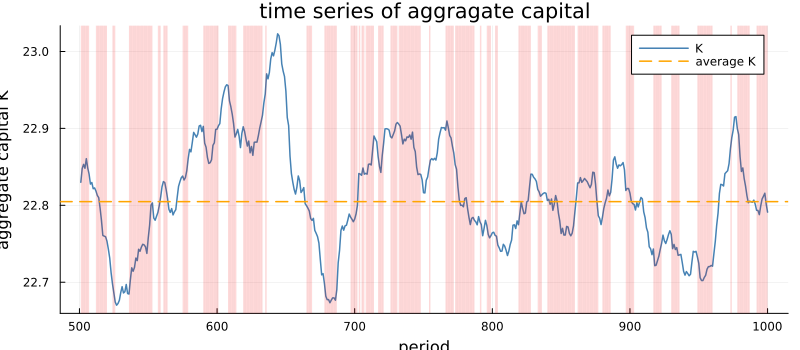

In [ ]:
# ===== 集計資本の時系列 =====
T_plot = min(500, p.T)
ts = p.T_discard+1:p.T_discard+T_plot

plot_K = plot(
    ts, K_series[ts],
    xlabel="period", ylabel="aggregate capital K",
    title="time series of aggragate capital",
    label="K", linewidth=1.5,
    color=:steelblue, legend=:topright,
    size=(800, 350)
)

# 景気状態のシェーディング
for t in ts
    if z_series[t] == 2  # 不況
        vspan!(plot_K, [t, t+1], alpha=0.15, color=:red, label=false)
    end
end

hline!(plot_K, [mean(K_series[p.T_discard+1:end])], 
       linestyle=:dash, color=:orange, label="average K", linewidth=1.5)

display(plot_K)

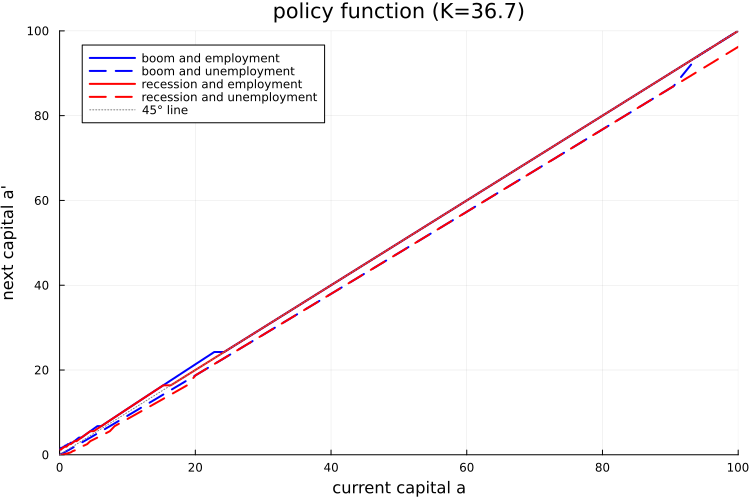

In [16]:
# ===== 政策関数 =====
iK_mid = div(p.n_K, 2)  # 中央の K グリッド点
K_mid = K_grid[iK_mid]

pol_g_e = pol_a[:, 1, 1, iK_mid]  # 好況・就業
pol_g_u = pol_a[:, 2, 1, iK_mid]  # 好況・失業
pol_b_e = pol_a[:, 1, 2, iK_mid]  # 不況・就業
pol_b_u = pol_a[:, 2, 2, iK_mid]  # 不況・失業

plot_pol = plot(
    title="policy function (K=$(@sprintf("%.1f", K_mid)))",
    xlabel="current capital a", ylabel="next capital a'",
    size=(750, 500), legend=:topleft
)

plot!(plot_pol, a_grid, pol_g_e, label="boom and employment", color=:blue, linewidth=2)
plot!(plot_pol, a_grid, pol_g_u, label="boom and unemployment", color=:blue, 
      linestyle=:dash, linewidth=2)
plot!(plot_pol, a_grid, pol_b_e, label="recession and employment", color=:red, linewidth=2)
plot!(plot_pol, a_grid, pol_b_u, label="recession and unemployment", color=:red, 
      linestyle=:dash, linewidth=2)

# 45度線
plot!(plot_pol, a_grid, a_grid, color=:gray, linestyle=:dot, 
      linewidth=1, label="45° line")

xlims!(plot_pol, 0, 100)  # 低資産域を拡大
ylims!(plot_pol, 0, 100)

display(plot_pol)

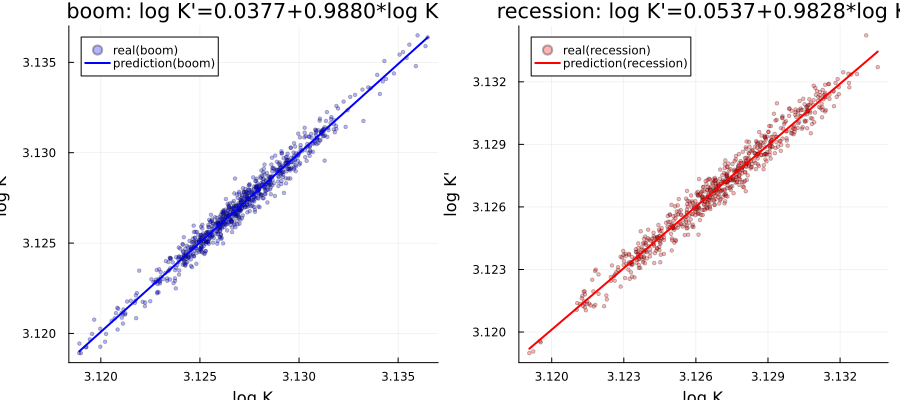

In [18]:
# ===== 予測ルールの精度（散布図）=====
ts_reg = (p.T_discard+1):(p.T-1)

# 好況期のデータ
idx_g = [t for t in ts_reg if z_series[t] == 1]
idx_b = [t for t in ts_reg if z_series[t] == 2]

logK_g = log.(K_series[idx_g])
logK1_g = log.(K_series[idx_g .+ 1])
logK_b = log.(K_series[idx_b])
logK1_b = log.(K_series[idx_b .+ 1])

# 予測値
a_g, b_g = km_coefs[1]
a_b, b_b = km_coefs[2]
pred_g = a_g .+ b_g .* logK_g
pred_b = a_b .+ b_b .* logK_b

p1 = scatter(logK_g, logK1_g, markersize=2, alpha=0.3, color=:blue, label="real(boom)")
plot!(p1, logK_g, pred_g, color=:blue, linewidth=2, label="prediction(boom)")
xlabel!(p1, "log K"); ylabel!(p1, "log K'")
title!(p1, @sprintf "boom: log K'=%.4f+%.4f*log K" a_g b_g)

p2 = scatter(logK_b, logK1_b, markersize=2, alpha=0.3, color=:red, label="real(recession)")
plot!(p2, logK_b, pred_b, color=:red, linewidth=2, label="prediction(recession)")
xlabel!(p2, "log K"); ylabel!(p2, "log K'")
title!(p2, @sprintf "recession: log K'=%.4f+%.4f*log K" a_b b_b)

plot_scatter = plot(p1, p2, layout=(1,2), size=(900, 400))
display(plot_scatter)

In [20]:
# ===== R² の確認 =====
# 最終予測ルールの R² を計算
SS_res_g = sum((logK1_g - pred_g).^2)
SS_tot_g = sum((logK1_g .- mean(logK1_g)).^2)
R2_g = 1.0 - SS_res_g / SS_tot_g

SS_res_b = sum((logK1_b - pred_b).^2)
SS_tot_b = sum((logK1_b .- mean(logK1_b)).^2)
R2_b = 1.0 - SS_res_b / SS_tot_b

@printf "R² prediction rule :\n"
@printf "  boom: R² = %.8f\n" R2_g
@printf "  recession: R² = %.8f\n" R2_b
println()
println("If R² is larger than 0.9999, 'almost perfect prediction' = the assumption of boundary rationality is valid.")

R² prediction rule :
  boom: R² = 0.97330390
  recession: R² = 0.96881378

If R² is larger than 0.9999, 'almost perfect prediction' = the assumption of boundary rationality is valid.


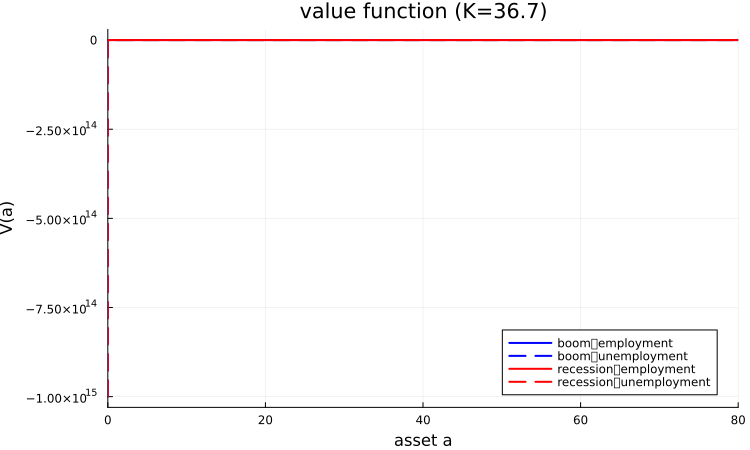

GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current font: 12539
GKS: glyph missing from current 

In [21]:
# ===== 価値関数 =====
iK_mid = div(p.n_K, 2)

plot_V = plot(
    title="value function (K=$(round(K_grid[iK_mid],digits=1)))",
    xlabel="asset a", ylabel="V(a)",
    size=(750, 450), legend=:bottomright
)

plot!(plot_V, a_grid, V[:, 1, 1, iK_mid], label="boom・employment", color=:blue, lw=2)
plot!(plot_V, a_grid, V[:, 2, 1, iK_mid], label="boom・unemployment", color=:blue, 
      ls=:dash, lw=2)
plot!(plot_V, a_grid, V[:, 1, 2, iK_mid], label="recession・employment", color=:red, lw=2)
plot!(plot_V, a_grid, V[:, 2, 2, iK_mid], label="recession・unemployment", color=:red, 
      ls=:dash, lw=2)

xlims!(plot_V, 0, 80)
display(plot_V)

最終分布のシミュレーション実行中...
  1.101711 seconds (40.09 M allocations: 1.941 GiB, 28.42% gc time, 8.46% compilation time)
Gini Coefficient: 0.0883
average asset: 22.8568
median asset: 24.2501


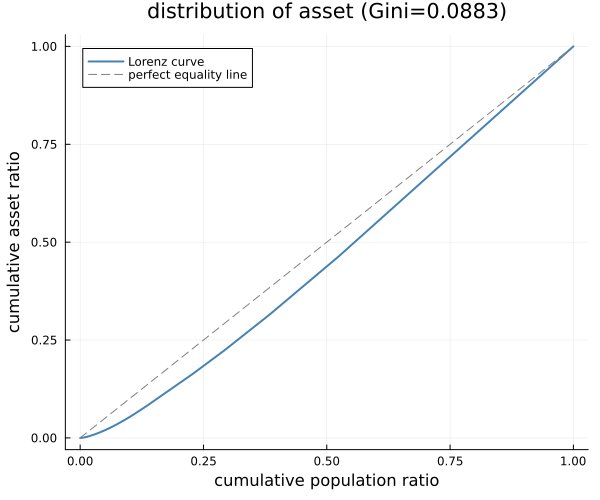

In [23]:
# ===== 資産分布（ローレンツ曲線・ジニ係数） =====
# 最後の時点でのクロスセクション分布を近似的に取得
# シミュレーション最終期の資産分布

function simulate_final_distribution(p, Π, pol_a, a_grid, K_grid, z_vals; seed=999)
    Random.seed!(seed)
    N = p.N
    T = p.T
    n_a = length(a_grid)

    a_now = fill(a_grid[div(n_a, 3)], N)
    s_now = ones(Int, N)
    Π_cum = cumsum(Π, dims=2)

    K_t = zeros(T)

    for t in 1:T
        K = mean(a_now)
        K_clamp = clamp(K, K_grid[1], K_grid[end])
        K_t[t] = K

        a_next = zeros(N)
        for i in 1:N
            s = s_now[i]
            iz_i = (s <= 2) ? 1 : 2
            iℓ_i = (mod(s-1, 2) == 0) ? 1 : 2
            ia = clamp(searchsortedfirst(a_grid, a_now[i]), 1, n_a)
            pol_slice = @view pol_a[ia, iℓ_i, iz_i, :]
            ap = interp1d(K_grid, collect(pol_slice), K_clamp)
            a_next[i] = clamp(ap, p.a_min, p.a_max)
        end

        rands = rand(N)
        for i in 1:N
            s = s_now[i]
            cum = Π_cum[s, :]
            r = rands[i]
            for k in 1:4
                if r <= cum[k]
                    s_now[i] = k
                    break
                end
            end
        end

        a_now .= a_next
    end

    return sort(a_now), K_t
end

println("最終分布のシミュレーション実行中...")
@time a_final, K_dist = simulate_final_distribution(p, Π, pol_a, a_grid, K_grid, z_vals)

# ジニ係数
function gini(x::Vector{Float64})
    n = length(x)
    x = sort(x)
    idx = 1:n
    return (2.0 * sum(idx .* x) / (n * sum(x))) - (n + 1.0) / n
end

G = gini(a_final)
@printf "Gini Coefficient: %.4f\n" G
@printf "average asset: %.4f\n" mean(a_final)
@printf "median asset: %.4f\n" median(a_final)

# ローレンツ曲線
N = length(a_final)
cum_share_pop = (1:N) ./ N
cum_share_wealth = cumsum(a_final) ./ sum(a_final)

plot_lorenz = plot(
    cum_share_pop, cum_share_wealth,
    label="Lorenz curve",
    xlabel="cumulative population ratio", ylabel="cumulative asset ratio",
    title=@sprintf("distribution of asset (Gini=%.4f)", G),
    color=:steelblue, linewidth=2,
    size=(600, 500)
)
plot!(plot_lorenz, [0,1], [0,1], color=:gray, linestyle=:dash, 
      linewidth=1, label="perfect equality line")
display(plot_lorenz)

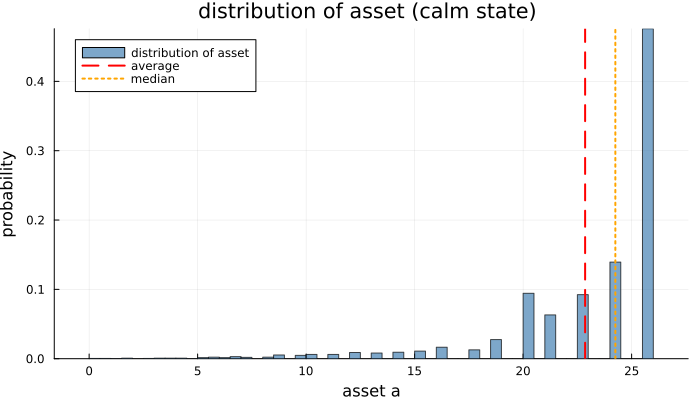

In [25]:
# ===== 資産分布のヒストグラム =====
plot_hist = histogram(
    a_final[a_final .< 120],
    bins=60, normalize=:probability,
    xlabel="asset a", ylabel="probability",
    title="distribution of asset (calm state) ",
    color=:steelblue, alpha=0.7,
    label="distribution of asset",
    size=(700, 400)
)

vline!(plot_hist, [mean(a_final)], color=:red, linewidth=2, 
       linestyle=:dash, label="average")
vline!(plot_hist, [median(a_final)], color=:orange, linewidth=2, 
       linestyle=:dot, label="median")

display(plot_hist)

## 9. 結果のまとめ

### 予測ルール（ALM = PLM 均衡）

収束した予測ルールは以下の形になる：

$$\log \bar{K}_{t+1} = a_g + b_g \log \bar{K}_t \quad (\text{好況時})$$
$$\log \bar{K}_{t+1} = a_b + b_b \log \bar{K}_t \quad (\text{不況時})$$

### Krusell-Smith の主要発見

1. **有界合理性の正当化**: 集計資本の平均だけを用いた線形予測ルールで R² > 0.9999 が達成される。すなわち、エージェントが資産分布の高次モーメントを無視しても予測精度はほぼ完全

2. **不平等の持続**: 借入制約と不完全保険により、資産分布は右に歪んだ定常分布に収束する

3. **景気循環と貯蓄行動**: 不況時はリスク回避的な予備的貯蓄が増加する傾向がある

4. **政策的含意**: 異質エージェントモデルでは、代表的エージェントモデルとは異なる再分配効果・厚生効果が生じる

In [26]:
# ===== 統計サマリー =====
println("="^50)
println("Krusell-Smith model reault summary")
println("="^50)
println()

println("[prediction rule (ALMa) ]")
a_g, b_g = km_coefs[1]
a_b, b_b = km_coefs[2]
@printf "  boom: log K' = %.6f + %.6f x log K\n" a_g b_g
@printf "  recession: log K' = %.6f + %.6f x log K\n" a_b b_b
@printf "  boom R² = %.8f\n" R2_g
@printf "  recession R² = %.8f\n" R2_b
println()

println("[Statistics of aggregated capital]")
K_stat = K_series[p.T_discard+1:end]
@printf "  average K: %.4f\n" mean(K_stat)
@printf "  standard deviation: %.4f\n" std(K_stat)
@printf "  coefficient of variation: %.4f%%\n" std(K_stat)/mean(K_stat)*100
println()

println("[asset inequality]")
@printf "  Gini coefficient: %.4f\n" G
@printf "  average asset: %.4f\n" mean(a_final)
@printf "  median asset: %.4f\n" median(a_final)
@printf "  top 10% asset share: %.1f%%\n" sum(a_final[Int(round(0.9*N))+1:end])/sum(a_final)*100
println()

println("[equilibrium price (around the average k)]")
K_avg = mean(K_stat)
r_g, w_g = get_prices(p.z_g, K_avg, p)
r_b, w_b = get_prices(p.z_b, K_avg, p)
@printf "  boom: r=%.4f, w=%.4f\n" r_g w_g
@printf "  recession: r=%.4f, w=%.4f\n" r_b w_b

Krusell-Smith model reault summary

[prediction rule (ALMa) ]
  boom: log K' = 0.037664 + 0.987956 x log K
  recession: log K' = 0.053687 + 0.982830 x log K
  boom R² = 0.97330390
  recession R² = 0.96881378

[Statistics of aggregated capital]
  average K: 22.8048
  standard deviation: 0.0618
  coefficient of variation: 0.2709%

[asset inequality]
  Gini coefficient: 0.0883
  average asset: 22.8568
  median asset: 24.2501


ArgumentError: ArgumentError: Number of format specifiers and number of provided args differ: 2 != 1